# 01b LSTM EDA And Data Preparation

This notebook loads the leakage-safe artifacts from `01_eda.ipynb`, adds deterministic sequence-model features, and saves horizon-specific LSTM datasets. No scaler is fit here; scaling is fit inside each strict train split by the LSTM estimator.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
for candidate in [cwd, cwd / "forecasting", cwd.parent, cwd.parent / "forecasting"]:
    if (candidate / "src" / "stock_forecast").exists():
        PROJECT_DIR = candidate
        break
else:
    raise RuntimeError("Cannot locate forecasting project directory with src/stock_forecast")

SRC_DIR = PROJECT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

ARTIFACT_DIR = PROJECT_DIR / "artifacts"
DATA_DIR = ARTIFACT_DIR / "data"
REPORTS_DIR = ARTIFACT_DIR / "reports"
PLOTS_DIR = ARTIFACT_DIR / "plots" / "lstm"
LSTM_DATA_DIR = DATA_DIR / "lstm"
for path in [LSTM_DATA_DIR, REPORTS_DIR, PLOTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_DIR = {PROJECT_DIR}")

PROJECT_DIR = /home/sapce/forecasting_stock_prices/forecasting


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from stock_forecast.artifacts import load_json, load_table, save_json, save_table
from stock_forecast.lstm_features import get_lstm_feature_columns, make_lstm_features, sequence_diagnostics

pd.set_option("display.max_columns", 160)
plt.style.use("default")

## Build LSTM Horizon Artifacts

In [3]:
HORIZONS = [
    {"name": "week", "horizon": 5},
    {"name": "month", "horizon": 21},
]
RECOMMENDED_LOOKBACKS = [20, 40, 60, 90, 126]
LIMITED_HISTORY_LOOKBACKS = [20, 40, 60]

base_summary = load_json(REPORTS_DIR / "eda_summary.json")
clean_ohlcv = load_table(DATA_DIR / "clean_ohlcv.parquet")
clean_ohlcv["date"] = pd.to_datetime(clean_ohlcv["date"])

lstm_featured = make_lstm_features(clean_ohlcv)
lstm_artifacts = []
lstm_summaries = {}

for spec in HORIZONS:
    horizon_name = spec["name"]
    horizon_dir = DATA_DIR / "horizons" / horizon_name
    base_model_df = load_table(horizon_dir / "model_dataset.parquet")
    base_model_df["date"] = pd.to_datetime(base_model_df["date"])
    base_payload = load_json(horizon_dir / "feature_columns.json")
    base_feature_cols = base_payload["feature_columns"]
    target_col = base_payload["target_column"]

    extra_cols = [col for col in lstm_featured.columns if col.startswith("lstm_")]
    lstm_model_df = base_model_df.merge(
        lstm_featured[["date", "ticker", *extra_cols]],
        on=["date", "ticker"],
        how="left",
    )
    lstm_feature_cols = get_lstm_feature_columns(lstm_model_df, base_feature_cols)

    lstm_horizon_dir = LSTM_DATA_DIR / "horizons" / horizon_name
    model_path = save_table(lstm_model_df, lstm_horizon_dir / "model_dataset.parquet")
    payload = {
        **base_payload,
        "feature_columns": lstm_feature_cols,
        "base_feature_columns": base_feature_cols,
        "lstm_added_feature_columns": [col for col in lstm_feature_cols if col not in base_feature_cols],
        "feature_source": "lstm_eda",
        "scaler_policy": "fit median imputer and RobustScaler inside each strict train split only",
        "recommended_lookbacks": RECOMMENDED_LOOKBACKS,
        "limited_history_lookbacks": LIMITED_HISTORY_LOOKBACKS,
    }
    save_json(payload, lstm_horizon_dir / "feature_columns.json")

    diagnostics = sequence_diagnostics(
        lstm_model_df,
        feature_cols=lstm_feature_cols,
        target_col=target_col,
        lookbacks=RECOMMENDED_LOOKBACKS,
    )
    diagnostics["horizon_name"] = horizon_name
    diagnostics["horizon"] = int(spec["horizon"])
    diagnostics["target_column"] = target_col
    save_json(diagnostics, lstm_horizon_dir / "sequence_diagnostics.json")

    lstm_artifacts.append({
        "horizon_name": horizon_name,
        "horizon": int(spec["horizon"]),
        "rows_model_dataset": int(len(lstm_model_df)),
        "feature_count": len(lstm_feature_cols),
        "added_lstm_feature_count": len(payload["lstm_added_feature_columns"]),
        "target_column": target_col,
        "model_dataset": str(model_path.relative_to(PROJECT_DIR)),
        "feature_columns": str((lstm_horizon_dir / "feature_columns.json").relative_to(PROJECT_DIR)),
        "sequence_diagnostics": str((lstm_horizon_dir / "sequence_diagnostics.json").relative_to(PROJECT_DIR)),
    })
    lstm_summaries[horizon_name] = diagnostics

lstm_eda_summary = {
    "source_eda_summary": base_summary.get("artifacts", {}),
    "rows_clean": int(len(clean_ohlcv)),
    "horizons": HORIZONS,
    "recommended_lookbacks": RECOMMENDED_LOOKBACKS,
    "limited_history_lookbacks": LIMITED_HISTORY_LOOKBACKS,
    "artifacts": lstm_artifacts,
}
save_json(lstm_eda_summary, REPORTS_DIR / "lstm_eda_summary.json")
display(pd.DataFrame(lstm_artifacts))

,horizon_name,horizon,rows_model_dataset,feature_count,added_lstm_feature_count,target_column,model_dataset,feature_columns,sequence_diagnostics
0,week,5,19407,160,33,target_return_5_next_open,artifacts/data/lstm/horizons/week/model_datase...,artifacts/data/lstm/horizons/week/feature_colu...,artifacts/data/lstm/horizons/week/sequence_dia...
1,month,21,19295,160,33,target_return_21_next_open,artifacts/data/lstm/horizons/month/model_datas...,artifacts/data/lstm/horizons/month/feature_col...,artifacts/data/lstm/horizons/month/sequence_di...


## Sequence Feasibility Diagnostics

In [4]:
for horizon_name, diagnostics in lstm_summaries.items():
    rows_by_ticker = pd.DataFrame(diagnostics["rows_by_ticker"])
    print(f"=== {horizon_name} sequence feasibility ===")
    display(rows_by_ticker)
    target_distribution = pd.Series(diagnostics["target_distribution"], name=horizon_name)
    display(target_distribution)

=== week sequence feasibility ===


,ticker,rows,date_start,date_end,max_feasible_lookback,sequences_lookback_20,sequences_lookback_40,sequences_lookback_60,sequences_lookback_90,sequences_lookback_126
0,CBOM,2758,2015-11-09,2026-06-07,126,2739,2719,2699,2669,2633
1,MBNK,537,2024-09-05,2026-06-07,126,518,498,478,448,412
2,SBER,4629,2007-11-28,2026-06-07,126,4610,4590,4570,4540,4504
3,SBERP,4629,2007-11-28,2026-06-07,126,4610,4590,4570,4540,4504
4,SVCB,636,2024-04-27,2026-06-07,126,617,597,577,547,511
5,T,1633,2020-03-13,2026-06-07,126,1614,1594,1574,1544,1508
6,VTBR,4585,2008-02-01,2026-06-07,126,4566,4546,4526,4496,4460


count     19407.000000
mean          0.000654
std           0.057441
min          -0.826040
p25          -0.021111
median        0.001016
p75           0.023865
max           0.584459
Name: week, dtype: float64

=== month sequence feasibility ===


,ticker,rows,date_start,date_end,max_feasible_lookback,sequences_lookback_20,sequences_lookback_40,sequences_lookback_60,sequences_lookback_90,sequences_lookback_126
0,CBOM,2742,2015-11-09,2026-05-22,126,2723,2703,2683,2653,2617
1,MBNK,521,2024-09-05,2026-05-22,126,502,482,462,432,396
2,SBER,4613,2007-11-28,2026-05-22,126,4594,4574,4554,4524,4488
3,SBERP,4613,2007-11-28,2026-05-22,126,4594,4574,4554,4524,4488
4,SVCB,620,2024-04-27,2026-05-22,126,601,581,561,531,495
5,T,1617,2020-03-13,2026-05-22,126,1598,1578,1558,1528,1492
6,VTBR,4569,2008-02-01,2026-05-22,126,4550,4530,4510,4480,4444


count     19295.000000
mean          0.002706
std           0.115971
min          -1.129788
p25          -0.044760
median        0.006187
p75           0.058624
max           0.687158
Name: month, dtype: float64

## Feature Missingness Diagnostics

=== week top feature missingness ===


lstm_close_position               0.000206
log_close                         0.000000
residual_return_beta_60           0.000000
bollinger_position_20             0.000000
bollinger_position_20_centered    0.000000
market_ret_equal_weight           0.000000
market_breadth_positive           0.000000
ret_minus_market                  0.000000
cs_ret_rank                       0.000000
cs_ret_pct_rank                   0.000000
cs_volume_shock_rank_20           0.000000
cs_volume_shock_pct_rank_20       0.000000
cs_volume_shock_rank_60           0.000000
cs_volume_shock_pct_rank_60       0.000000
market_beta_20                    0.000000
residual_return_beta_20           0.000000
residual_momentum_5_beta_20       0.000000
residual_momentum_20_beta_20      0.000000
residual_momentum_60_beta_20      0.000000
high_low_range_over_atr_14        0.000000
Name: missing_fraction, dtype: float64

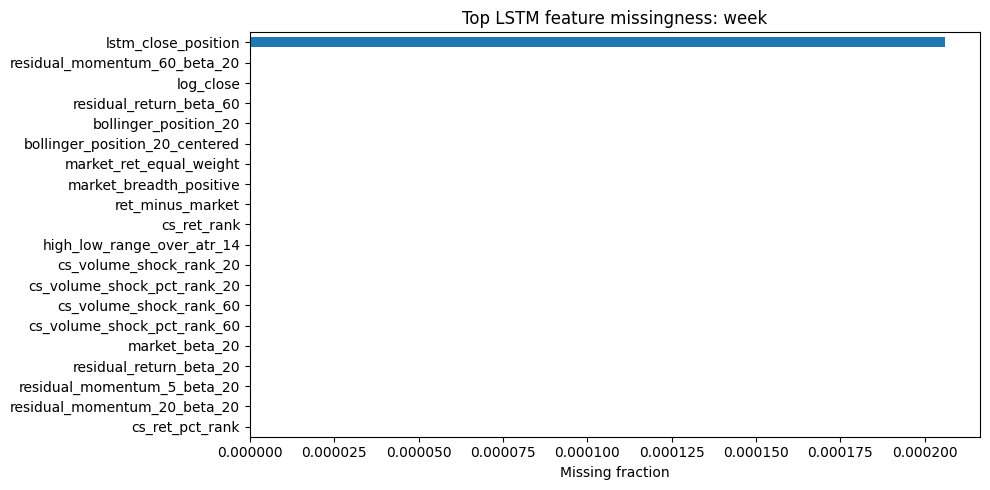

=== month top feature missingness ===


lstm_close_position               0.000207
log_close                         0.000000
residual_return_beta_60           0.000000
bollinger_position_20             0.000000
bollinger_position_20_centered    0.000000
market_ret_equal_weight           0.000000
market_breadth_positive           0.000000
ret_minus_market                  0.000000
cs_ret_rank                       0.000000
cs_ret_pct_rank                   0.000000
cs_volume_shock_rank_20           0.000000
cs_volume_shock_pct_rank_20       0.000000
cs_volume_shock_rank_60           0.000000
cs_volume_shock_pct_rank_60       0.000000
market_beta_20                    0.000000
residual_return_beta_20           0.000000
residual_momentum_5_beta_20       0.000000
residual_momentum_20_beta_20      0.000000
residual_momentum_60_beta_20      0.000000
high_low_range_over_atr_14        0.000000
Name: missing_fraction, dtype: float64

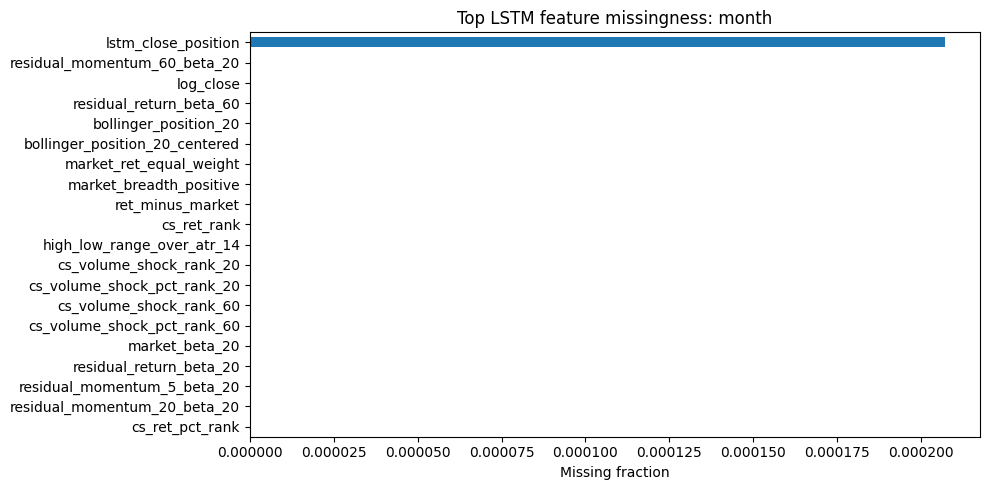

In [5]:
for horizon_name, diagnostics in lstm_summaries.items():
    missingness = pd.Series(diagnostics["top_feature_missingness"], name="missing_fraction")
    print(f"=== {horizon_name} top feature missingness ===")
    display(missingness.head(20))
    if not missingness.empty:
        fig, ax = plt.subplots(figsize=(10, max(4, len(missingness.head(20)) * 0.25)))
        missingness.head(20).sort_values().plot(kind="barh", ax=ax)
        ax.set_title(f"Top LSTM feature missingness: {horizon_name}")
        ax.set_xlabel("Missing fraction")
        fig.tight_layout()
        fig.savefig(PLOTS_DIR / f"{horizon_name}_lstm_feature_missingness.png", dpi=150, bbox_inches="tight")
        plt.show()